In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from math import ceil

In [2]:
outliermeth = 'quant_outlier'
outliertreatment = 'elim'
normtype = 'minmax'

base_dir = Path().resolve()
folderpath = os.path.join(base_dir, "..","Biometrics", "Outputs", f'outlier_{outliertreatment}', outliermeth)
folderpath = os.path.abspath(folderpath)
folderpath


'C:\\Users\\josee\\OneDrive\\Documentos\\GitHub\\neurohumanities-lab\\OfflineProcessing\\Biometrics\\Outputs\\outlier_elim\\quant_outlier'

In [3]:
def remove_outliers_winsor(col, p_low=0.05, p_high=0.95):
    lower = col.quantile(p_low)
    upper = col.quantile(p_high)
    return col.clip(lower=lower, upper=upper)

def remove_outliers_iqr(col, treatment='elim'):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    if treatment == 'impute':
        return col.clip(lower=lower, upper=upper)
    else:
        return col[(col >= lower) & (col <= upper)]

scenedata = {}
non_norm_data = {0:pd.read_csv(os.path.join(folderpath,'non-normalized','biometric_feat_mat_scene_0_nonnorm.csv'))}
for scene in range(1,5):
    dataholder = pd.read_csv(os.path.join(folderpath,f"biometric_feat_mat_scene_{scene}_{normtype}.csv"))
    scenedata_nonnorm = pd.read_csv(os.path.join(folderpath,'non-normalized',rf'biometric_feat_mat_scene_{scene}_nonnorm.csv'))
    non_norm_data.update({scene:scenedata_nonnorm})
    scenedata.update({scene:dataholder})

In [4]:
# scenedata[4]

In [5]:
# non_norm_data[0]

In [6]:
outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", f'outlier_{outliertreatment}', outliermeth, normtype)
outpath = os.path.abspath(outpath)


# def plot_bars(data, scene=int, normtype=str, savecond=False, savepath=str, showfig=True):
#     means = data.mean()
#     plt.figure(figsize=(10, 6))
#     plt.bar(means.index, means.values, color='#1f77b4', edgecolor='black')
#     plt.title(f'Media de características escena {scene} - Normalización {normtype}')
#     plt.ylabel('Valor medio')
#     plt.xticks(rotation=45, ha='right')
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     if savecond:
#         plt.savefig(os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'), dpi=300, bbox_inches='tight')
#     if showfig:
#         plt.show()
#     else:
#         plt.close()

In [7]:
def plot_bars(data, scene, normtype, savecond=False, savepath=None, showfig=True):
    """
    Plotea barras de la media de 'data' con barras de error de desviación estándar.
    """
    # calcular media y desviación estándar
    means = data.mean()
    stds = np.array(data.std().values)
    errors = [stds / np.sqrt(data.shape[0]), stds / np.sqrt(data.shape[0])]

    plt.figure(figsize=(10, 6))
    # plot de barras con error bars
    plt.bar(
        means.index,
        means.values,
        yerr=errors,
        capsize=5,
        edgecolor='black'
    )
    plt.title(f'Media de características escena {scene} - Normalización {normtype}')
    plt.ylabel('Valor medio')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if savecond:
        plt.savefig(
            os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'),
            dpi=300,
            bbox_inches='tight'
        )
    if showfig:
        plt.show()
    else:
        plt.close()

In [8]:
def compare_baseline_scenes(data,savepath,show=True,save=True):
    features = data[1].drop('Subject', axis=1).columns
    n_features = len(features)
    n_scenes = len(data)

    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(n_scenes))
    x_labels = ["Baseline"] + [f"Scene {i+1}" for i in range(4)]
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        values = []
        errors = []
        for key in data.keys():
            value = data[key][feature].mean()
            error = data[key][feature].std() / np.sqrt(len(data[key][feature]))
            values.append(value)
            errors.append(error)
        ax.bar(x_positions, values, yerr=errors, capsize=6)
        if idx // ncols == nrows - 1: 
                ax.set_xticks(x_positions)
                ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
                ax.set_xticklabels([])

        ax.set_ylabel("Add units")
        
        for j in range(n_features, len(axes)):
            axes[j].axis('off')

        ax.set_title(feature)
    
    fig.suptitle(f'Comparison of baseline and scene values accross features (prior to normalization). \nOutlier method: {outliermeth}.')
    plt.tight_layout()
    
    if save:
        plt.savefig(
            os.path.join(savepath, f'feature_comparison_{outliermeth}_nonnorm.png'),
            dpi=300,
            bbox_inches='tight'
        )
    
    if show:
        plt.show()
    
    plt.close(fig)


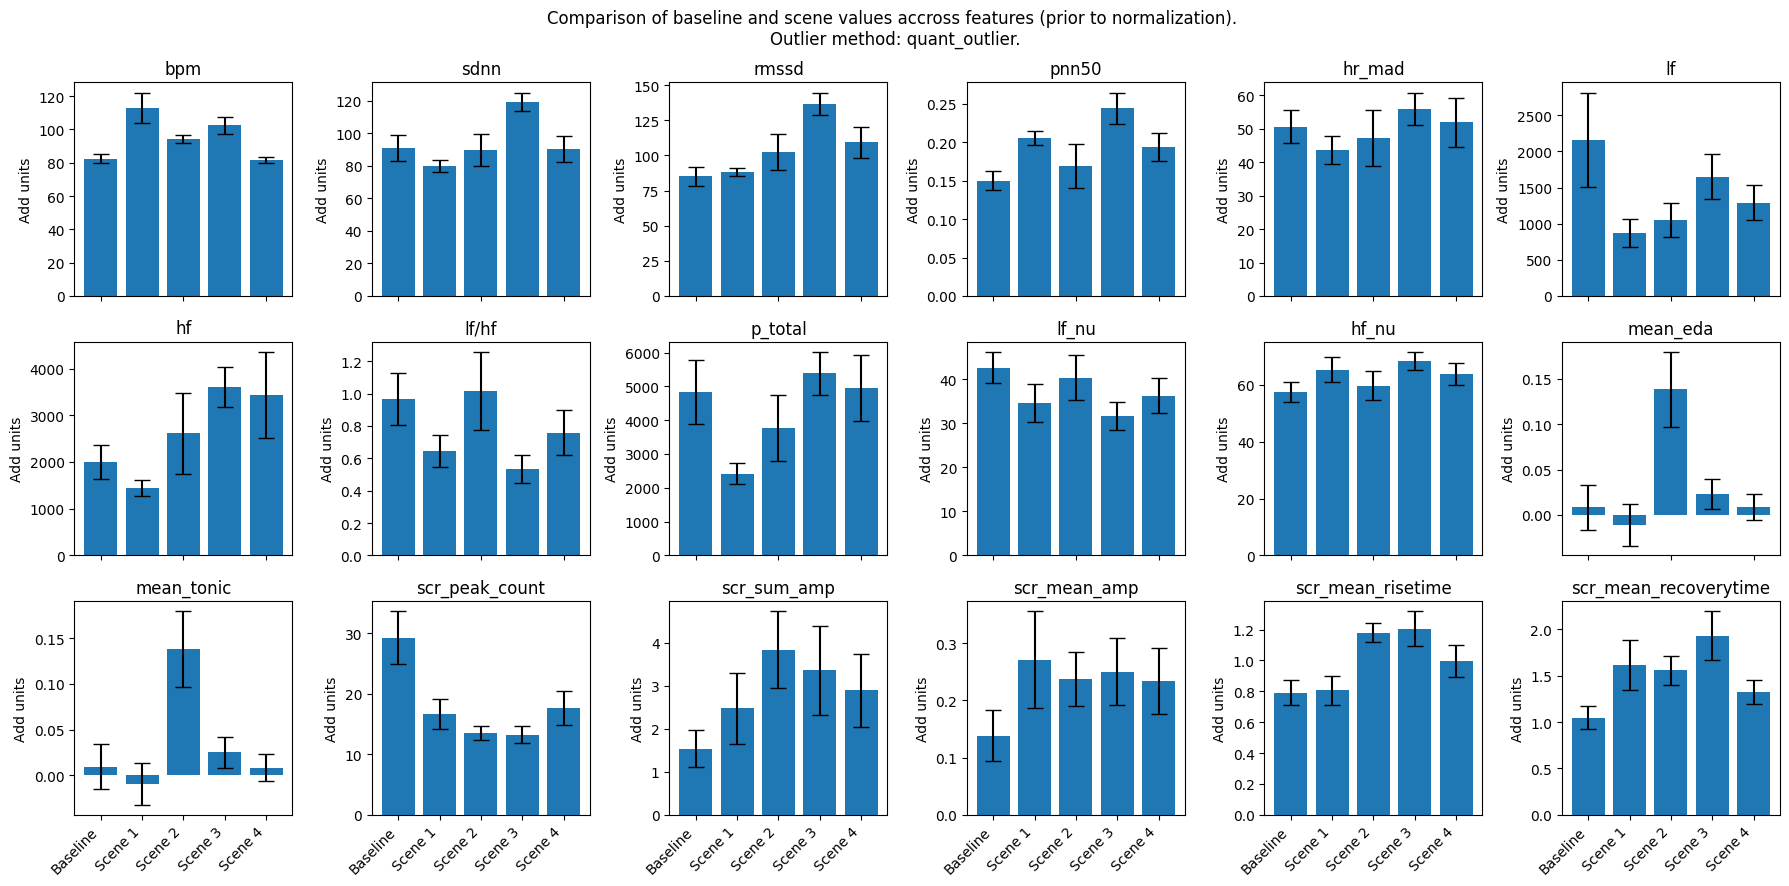

In [9]:
# for probe in range(1, 5):
#     plot_bars(
#         scenedata[probe].drop("Subject", axis=1),
#         probe,
#         normtype,
#         savecond=False,
#         savepath=outpath,
#         showfig=False,
#     )

nonnorm_outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", f'outlier_{outliertreatment}', outliermeth, 'non_norm')

compare_baseline_scenes(non_norm_data,nonnorm_outpath,show=True,save=False)

In [10]:
non_norm_data[3].drop('Subject', axis=1).dropna()

,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,164.365971,132.219350,149.818175,0.303797,85.9375,1296.090196,2059.325665,0.629376,3355.415861,38.626813,61.373187,0.009317,0.009089,20,0.303490,0.015175,0.650000,0.982143
1,152.102377,151.589901,139.412634,0.296875,109.3750,985.405568,4644.389513,0.212171,5629.795081,17.503400,82.496600,0.026684,0.026693,5,0.205959,0.041192,0.650000,5.500000
2,91.596330,117.800725,146.432282,0.218750,31.2500,757.549784,3482.011957,0.217561,4239.561741,17.868587,82.131413,-0.007472,-0.006858,9,0.306149,0.034017,1.222222,3.000000
3,92.530120,129.083685,182.116099,0.245283,39.0625,293.682833,2727.169537,0.107688,3020.852370,9.721853,90.278147,-0.007493,-0.007410,10,0.480404,0.048040,1.475000,2.305556
4,103.572519,160.061100,199.674841,0.250000,62.5000,550.521600,5334.521355,0.103200,5885.042955,9.354589,90.645411,-0.003431,-0.004394,27,0.342504,0.013173,0.538462,0.630952
5,100.702622,157.484444,177.532013,0.211538,46.8750,1723.003999,5999.462752,0.287193,7722.466751,22.311575,77.688425,-0.023351,-0.023370,20,0.437738,0.021887,0.587500,0.783333
6,109.990557,121.862416,115.772710,0.122222,62.5000,3340.782521,6571.043318,0.508410,9911.825839,33.705016,66.294984,-0.021928,-0.018657,6,1.344445,0.224074,1.458333,3.625000
7,110.678383,112.241643,115.461179,0.135802,39.0625,1646.535178,4537.992536,0.362833,6184.527714,26.623459,73.376541,-0.013049,-0.012558,15,0.420786,0.028052,0.950000,1.318182
8,109.534426,121.270613,142.400373,0.116279,31.2500,1288.992168,3400.934865,0.379011,4689.927033,27.484269,72.515731,-0.050638,-0.051721,8,0.969782,0.121223,2.031250,2.178571
9,109.040675,139.240327,165.975173,0.150685,54.6875,1112.296061,3621.034288,0.307176,4733.330349,23.499227,76.500773,0.164744,0.165153,8,1.390860,0.173857,1.906250,2.321429


In [11]:
def wilcoxon_paired(baseline_df, scene_df, alpha=0.05):
    features = baseline_df.columns

    baseline_no_na = baseline_df.dropna()
    scene_no_na = scene_df.dropna()
    n = min(len(baseline_no_na), len(scene_no_na))

    p_raw = []
    stats = []

    for feat in features:
        stat, p = wilcoxon(
            baseline_no_na[feat][0:n],
            scene_no_na[feat][0:n],
            zero_method='wilcox', 
            alternative='two-sided'
        )
        stats.append(stat)
        p_raw.append(p)

    reject, p_holm, _, _ = multipletests(p_raw, alpha=alpha, method='holm')

    results = pd.DataFrame({
        'feature': features,
        'statistic': stats,
        'p_raw': p_raw,
        'p_holm': p_holm,
        'reject_H0': reject
    })

    return results

multitests = []
for probe in range(1,5):
    re = wilcoxon_paired(non_norm_data[0].drop('Subject',axis=1), non_norm_data[probe].drop('Subject',axis=1))
    # re.to_csv(os.path.join(nonnorm_outpath,f'wilcoxon_multitest_baseline_scene{probe}.csv'))
    multitests.append(re)

c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if

In [12]:
multitests[0][multitests[0]['feature'] == 'bpm']

,feature,statistic,p_raw,p_holm,reject_H0
0,bpm,35.0,0.007296,0.11673,False


In [13]:
def compare_pvalues(df_list, savepath, show=True, save=True, alpha=0.05, eps=1e-12):
    features = list(df_list[0]["feature"])
    n_features = len(features)
    n_scenes = len(df_list)

    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(n_scenes))
    x_labels = [f"Scene {i+1}" for i in range(n_scenes)]

    for idx, feature in enumerate(features):
        ax = axes[idx]

        p_values = []
        for sdf in df_list:
            m = sdf.loc[sdf["feature"] == feature, "p_holm"]
            pv = float(m.iloc[0]) if len(m) else np.nan
            p_values.append(pv)

        # --- Ajustar valores muy pequeños ---
        plot_vals = []
        for p in p_values:
            if np.isfinite(p):
                if p < 0.01:
                    plot_vals.append(0.01)
                else:
                    plot_vals.append(p)
            else:
                plot_vals.append(np.nan)

        ax.bar(x_positions, plot_vals)
        if idx // ncols == nrows - 1: 
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])

        # --- Escala lineal 0.01 a 0.5 ---
        ax.set_ylim(0.01, 0.5)
        if idx % ncols == 0: 
            ax.set_ylabel("p (0.01 a 0.5)")
        else:
            ax.set_ylabel("")

        # Línea de significancia (solo si cae en el rango)
        if 0.01 <= alpha <= 0.5:
            ax.axhline(alpha, linestyle="--", linewidth=1, alpha=0.7)

        # Marca estrella si p < alpha
        for x, pv in zip(x_positions, p_values):  # usar valores originales para el criterio
            if np.isfinite(pv) and pv < alpha:
                ax.text(x, 0.02, "★", ha="center", va="bottom", fontsize=9)  # fijo justo arriba del mínimo

        ax.grid(axis="y", linestyle=":", alpha=0.35)
        ax.set_title(feature)

    # Apaga ejes sobrantes
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Comparison of adjusted p-values (Holm) in baseline vs. scene analysis\n(p clipped to 0.01–0.5; discontinuous line = α)", fontsize=14)
    plt.tight_layout()

    if save:
        plt.savefig(os.path.join(savepath, "p_values_comparison_scaled.png"), dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


compare_pvalues(multitests, savepath=nonnorm_outpath, show=False, save=False)

In [14]:
list(scenedata)

[1, 2, 3, 4]

In [15]:
def boxplot_feature_by_context(dfs, labels, feature, title=None, colors=None, showfig=True):
    dfs_list = [dfs[i] for i in sorted(dfs.keys())]

    # Extrae los valores de la característica en cada contexto
    data = [df[feature] for df in dfs_list]

    # Colores por defecto si no se especifican
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(dfs)]

    # Gráfico
    plt.figure(figsize=(8, 6))
    box = plt.boxplot(data, patch_artist=True, tick_labels=labels)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    for component in ['whiskers', 'caps', 'medians']:
        for element in box[component]:
            element.set_color('black')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('Valor')
    plt.title(title if title else f'Comparación de "{feature}" entre escenas')
    plt.tight_layout()
    if showfig:
        plt.show()
    else:
        plt.close()

labels = ['Scene 1', 'Scene 2', 'Scene 3', 'Scene 4']
feats = list(scenedata[1].columns)
boxplot_feature_by_context(scenedata, labels, feats[15], showfig=False)

In [16]:
def compare_norm_scene(scenedata,savepath,show=True,save=True):
    features = scenedata[1].drop('Subject', axis=1).columns
    n_features = len(features)
    n_scenes = len(scenedata)

    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(n_scenes))
    x_labels = [f"Scene {i+1}" for i in range(n_scenes)]
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        values = []
        errors = []
        for key in scenedata.keys():
            value = scenedata[key][feature].mean()
            error = scenedata[key][feature].std() / np.sqrt(len(scenedata[key][feature]))
            values.append(value)
            errors.append(error)

        ax.bar(x_positions, values, yerr=errors, capsize=5)
        if idx // ncols == nrows - 1: 
                ax.set_xticks(x_positions)
                ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
                ax.set_xticklabels([])

        if idx % ncols == 0: 
            ax.set_ylabel("Normalized value (a.u.)")
        else:
            ax.set_ylabel("")
        
        for j in range(n_features, len(axes)):
            axes[j].axis('off')

        ax.set_title(feature)
    
    fig.suptitle(f'Comparison of normalized scene values accross features. \nOutlier method: {outliermeth}, Normalization: {normtype}.')
    plt.tight_layout()
    
    if save:
        plt.savefig(
            os.path.join(savepath, f'feature_comparison_{outliermeth}_{normtype}.png'),
            dpi=300,
            bbox_inches='tight'
        )
    
    if show:
        plt.show()
    
    plt.close(fig)

compare_norm_scene(scenedata,savepath=outpath,show=False,save=True)

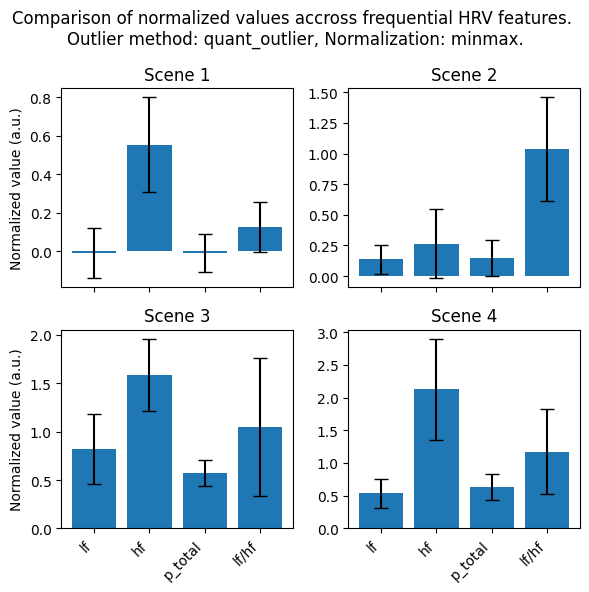

In [17]:
def compare_feature_scenes(scenedata, features, title, savename, savepath,show=True,save=True):
    n_features = len(features)

    ncols = 2
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(0,len(features)))
    x_labels = features
    
    for i in range(0,len(axes)):
        ax = axes[i]
        values = []
        errors = []
        for idx in range(0, len(features)):
            value = scenedata[i+1][features[idx]].mean()
            error = scenedata[i+1][features[idx]].std() / np.sqrt(len(scenedata[i + 1][features[idx]]))
            values.append(value)
            errors.append(error)


        ax.bar(x_positions, values, yerr=errors, capsize=5)
        if i // ncols == nrows - 1: 
                ax.set_xticks(x_positions)
                ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
                ax.set_xticklabels([])

        if i % ncols == 0: 
            ax.set_ylabel("Normalized value (a.u.)")
        else:
            ax.set_ylabel("")

        ax.set_title(f"Scene {i + 1}")
    
    fig.suptitle(title)
    plt.tight_layout()
    
    if save:
        plt.savefig(
            os.path.join(savepath, savename),
            dpi=300,
            bbox_inches='tight'
        )
    
    if show:
        plt.show()
    
    plt.close(fig)

feats = ['lf', 'hf', 'p_total','lf/hf']
title = f'Comparison of normalized values accross frequential HRV features. \nOutlier method: {outliermeth}, Normalization: {normtype}.'
savename = f'freqfeats_comparison_{outliermeth}_{normtype}.png'
compare_feature_scenes(scenedata, feats, title, savename, savepath=outpath,show=True,save=True)

In [18]:
feat_cols = [col for col in scenedata[1].columns if col not in ["Subject"]]

org_per_feat = {}
subjects = [1, 2, 3, 4, 6, 8, 9]
for feat in feat_cols:
    aggdata_np = np.zeros([len(subjects),5])
    for i in range(0,len(subjects)):
        scene1 = scenedata[1][scenedata[1]['Subject']==subjects[i]][feat].median()
        scene2 = scenedata[2][scenedata[2]['Subject']==subjects[i]][feat].median()
        scene3 = scenedata[3][scenedata[3]['Subject']==subjects[i]][feat].median()
        scene4 = scenedata[4][scenedata[4]['Subject']==subjects[i]][feat].median()

        aggdata_np[i,:] = np.array([subjects[i], scene1, scene2, scene3, scene4])

    columns = ['Subject', 'scene1', 'scene2', 'scene3', 'scene4']
    aggdata_df = pd.DataFrame(aggdata_np, columns=columns).dropna()

    org_per_feat.update({feat:aggdata_df})

org_per_feat['bpm']

,Subject,scene1,scene2,scene3,scene4
1,2.0,1.050384,0.939479,1.802412,0.445516
2,3.0,2.971856,0.453983,0.938748,0.099547
3,4.0,9.968510,1.438534,1.888262,0.961683
4,6.0,-0.803477,0.944277,-0.475676,-1.028624
5,8.0,0.634277,2.048871,0.743054,-0.218300


In [19]:
np.zeros([1,4])

array([[0., 0., 0., 0.]])

In [20]:
friedman_list = []
for feat in feat_cols:
    data = org_per_feat[feat].drop('Subject', axis=1)
    stat, p = friedmanchisquare(data['scene1'], data['scene2'], data['scene3'], data['scene4'])
    #stat, p = kruskal(data['scene1'], data['scene2'], data['scene3'], data['scene4'])
    friedman_list.append([stat, p])

friedman_df = pd.DataFrame(friedman_list, columns=['Statistic', 'p-value'], index=feat_cols)


In [21]:
friedman_df

,Statistic,p-value
bpm,9.240000,0.026264
sdnn,2.040000,0.564146
rmssd,1.080000,0.781904
pnn50,1.560000,0.668493
hr_mad,0.446809,0.930412
lf,3.240000,0.356081
hf,3.240000,0.356081
lf/hf,0.600000,0.896432
p_total,5.880000,0.117597
lf_nu,0.360000,0.948376


In [22]:
friedman_df[friedman_df['p-value']<0.05]

,Statistic,p-value
bpm,9.24,0.026264
